✅ Đang chạy tại thư mục: d:\HCMUT\NMTTNT\ai-ambulance-coordinator

🚀 KHỞI TẠO PIPELINE THỰC NGHIỆM VÀ ĐÁNH GIÁ HIỆU NĂNG...
-----------------------------------------------------------------
[1/4] Đang huấn luyện và đo lường Scikit-Learn...
Đang tải dữ liệu từ data/Final_Augmented_dataset_Diseases_and_Symptoms.csv...
Đang chuyển đổi sang Sparse Matrix để tăng tốc...
Đang huấn luyện mô hình sklearnNaiveBayes...
[HOÀN TẤT] Huấn luyện thành công!
[2/4] Đang huấn luyện và đo lường NumPy (From Scratch)...
Đang tải dữ liệu từ data/Final_Augmented_dataset_Diseases_and_Symptoms.csv...
Đang chuyển đổi sang Sparse Matrix để tăng tốc...
Đang huấn luyện mô hình simpleClassifierModel...
[HOÀN TẤT] Huấn luyện thành công!
[3/4] Đang đánh giá chỉ số và chạy Test dự đoán thực tế...
Đang đánh giá mô hình trên tập Test...
Đang đánh giá mô hình trên tập Test...

   -> Triệu chứng test: ['anxiety and nervousness', 'dizziness']
   -> Kết quả Scikit-Learn: acute stress reaction
   -> Kết quả NumPy:        acu

,Scikit-Learn (Scale-up),NumPy (From Scratch)
Metrics,,
Training Time (sec),12.0877,11.2691
Peak Memory (MB),2783.9700,1696.9100
Inference Time - 1000 Queries (sec),10.2377,0.8718
Accuracy (%),84.5300,84.5300


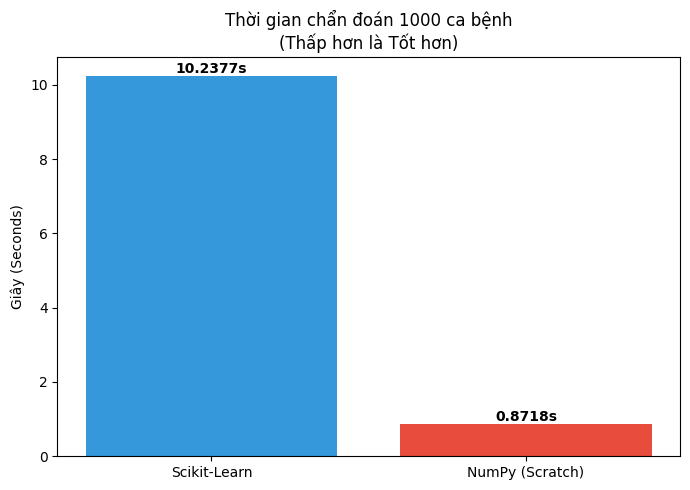

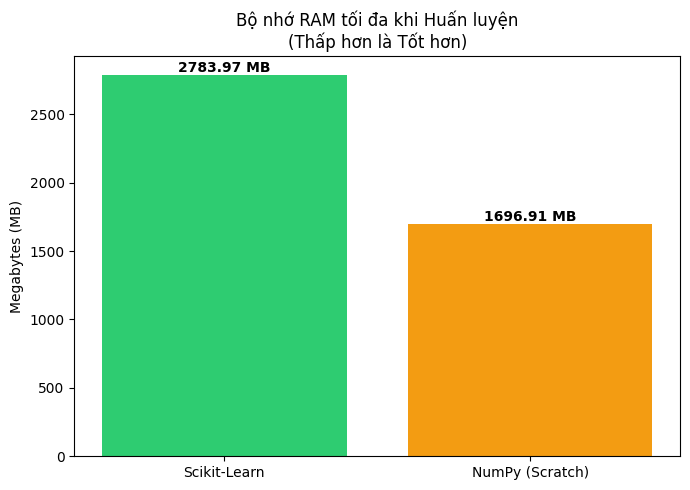

In [2]:
# ==============================================================================
# PHẦN 1: SETUP MÔI TRƯỜNG & THƯ VIỆN
# ==============================================================================
import os
import sys
import time
import tracemalloc
import random
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# Đảm bảo Notebook luôn đứng ở thư mục gốc dự án
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"✅ Đang chạy tại thư mục: {os.getcwd()}")
from modules.core.disease_classifier import DiseaseClassifier

# ==============================================================================
# PHẦN 2: CẤU HÌNH THỰC NGHIỆM (CONFIGURATION)
# ==============================================================================
DATASET_PATH = "data/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
NUM_INFERENCE_QUERIES = 1000  # Số lượng bệnh nhân giả lập để stress test

print("\n🚀 KHỞI TẠO PIPELINE THỰC NGHIỆM VÀ ĐÁNH GIÁ HIỆU NĂNG...")
print("-" * 65)

# Khởi tạo mô hình
clf_sklearn = DiseaseClassifier(model_name="sklearnNaiveBayes")
clf_simple = DiseaseClassifier(model_name="simpleClassifierModel")

benchmark_results = {
    "Metrics": ["Training Time (sec)", "Peak Memory (MB)", "Inference Time - 1000 Queries (sec)", "Accuracy (%)"]
}

# ==============================================================================
# PHẦN 3: ĐO LƯỜNG HUẤN LUYỆN & BỘ NHỚ (TRAINING BENCHMARK)
# ==============================================================================
print("[1/4] Đang huấn luyện và đo lường Scikit-Learn...")
tracemalloc.start()
start_t = time.time()
clf_sklearn.train(DATASET_PATH)
time_sk = time.time() - start_t
_, peak_mem_sk = tracemalloc.get_traced_memory()
tracemalloc.stop()

print("[2/4] Đang huấn luyện và đo lường NumPy (From Scratch)...")
tracemalloc.start()
start_t = time.time()
clf_simple.train(DATASET_PATH)
time_sim = time.time() - start_t
_, peak_mem_sim = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Chuyển đổi Memory sang MB
mem_sk_mb = peak_mem_sk / (1024 * 1024)
mem_sim_mb = peak_mem_sim / (1024 * 1024)

# ==============================================================================
# PHẦN 4: ĐÁNH GIÁ ĐỘ CHÍNH XÁC & TEST DỰ ĐOÁN THỰC TẾ
# ==============================================================================
print("[3/4] Đang đánh giá chỉ số và chạy Test dự đoán thực tế...")
eval_sk = clf_sklearn.evaluate()
eval_sim = clf_simple.evaluate()

acc_sk = eval_sk.get('Accuracy', eval_sk.get('accuracy', 0)) * 100
acc_sim = eval_sim.get('Accuracy', eval_sim.get('accuracy', 0)) * 100

# Lấy tự động 2 triệu chứng đầu tiên để test sanity check
sample_symptoms = [clf_sklearn.symptoms_vocab[0], clf_sklearn.symptoms_vocab[5]]
print(f"\n   -> Triệu chứng test: {sample_symptoms}")
print(f"   -> Kết quả Scikit-Learn: {clf_sklearn.predict(sample_symptoms)}")
print(f"   -> Kết quả NumPy:        {clf_simple.predict(sample_symptoms)}\n")

# ==============================================================================
# PHẦN 5: STRESS TEST TỐC ĐỘ SUY DIỄN (INFERENCE BENCHMARK)
# ==============================================================================
print(f"[4/4] Đang Stress Test tốc độ suy diễn ({NUM_INFERENCE_QUERIES} truy vấn)...")
vocab = list(clf_sklearn.symptoms_vocab)

# Tạo dữ liệu ảo
synthetic_patients = [random.sample(vocab, random.randint(3, 6)) for _ in range(NUM_INFERENCE_QUERIES)]

start_t = time.time()
for patient in synthetic_patients:
    _ = clf_sklearn.predict(patient)
inf_sk = time.time() - start_t

start_t = time.time()
for patient in synthetic_patients:
    _ = clf_simple.predict(patient)
inf_sim = time.time() - start_t

# ==============================================================================
# PHẦN 6: XUẤT BÁO CÁO & VẼ BIỂU ĐỒ TRỰC QUAN
# ==============================================================================
print("\n✅ HOÀN TẤT THỰC NGHIỆM! ĐANG TẠO BÁO CÁO...\n")

benchmark_results["Scikit-Learn (Scale-up)"] = [
    round(time_sk, 4), round(mem_sk_mb, 2), round(inf_sk, 4), round(acc_sk, 2)
]
benchmark_results["NumPy (From Scratch)"] = [
    round(time_sim, 4), round(mem_sim_mb, 2), round(inf_sim, 4), round(acc_sim, 2)
]

# Tạo DataFrame
df_report = pd.DataFrame(benchmark_results)
df_report.set_index("Metrics", inplace=True)

# Hiển thị bảng
display(HTML("<h3 style='color:#2E86C1;'>📊 Báo Cáo Thực Nghiệm Hiệu Năng (Benchmark Report)</h3>"))
display(df_report.style.highlight_min(axis=1, color='lightgreen', subset=pd.IndexSlice[["Training Time (sec)", "Peak Memory (MB)", "Inference Time - 1000 Queries (sec)"], :]) \
                .highlight_max(axis=1, color='lightgreen', subset=pd.IndexSlice[["Accuracy (%)"], :]) \
                .format(precision=4))

# Vẽ biểu đồ 1
fig1, ax1 = plt.subplots(figsize=(7, 5))
bars1 = ax1.bar(["Scikit-Learn", "NumPy (Scratch)"], [inf_sk, inf_sim], color=['#3498DB', '#E74C3C'])
ax1.set_title(f"Thời gian chẩn đoán {NUM_INFERENCE_QUERIES} ca bệnh\n(Thấp hơn là Tốt hơn)")
ax1.set_ylabel("Giây (Seconds)")
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}s", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()

# Vẽ biểu đồ 2
fig2, ax2 = plt.subplots(figsize=(7, 5))
bars2 = ax2.bar(["Scikit-Learn", "NumPy (Scratch)"], [mem_sk_mb, mem_sim_mb], color=['#2ECC71', '#F39C12'])
ax2.set_title("Bộ nhớ RAM tối đa khi Huấn luyện\n(Thấp hơn là Tốt hơn)")
ax2.set_ylabel("Megabytes (MB)")
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f} MB", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()

plt.show()